
# Deliverable 2 - Week4 version
## Fair public EV charging access across NSW (SDG 11)

**Course:** COMM5501 Data Visualisation and Communication (T2 2026)

This notebook documents the process of building and iterating the data visualisation that
supports my data story. It contains the full data pipeline, every key chart iteration, and
the rationale for each change, mapped to the *Data Analysis and Visualisation* rubric used to
assess Deliverable 2.

---

### Project recap (from Deliverable 1)

- **Primary SDG:** SDG 11 - Sustainable Cities and Communities (secondary links: SDG 13 Climate Action, SDG 7 Affordable & Clean Energy).
- **Topic question:** *How can NSW transport and energy planners improve public EV charging access in outer-suburban areas so the shift to electric vehicles is geographically fair?*
- **Call to Action (CtA):** NSW transport and energy planners should prioritise public EV charging rollout in under-served, high-population outer-suburban LGAs, rather than letting infrastructure concentrate in already well-served inner-city areas.
- **Target Audience (TA):** NSW transport and energy planners / local councils responsible for charging-infrastructure rollout.

### What this graph needs to do
The visualisation must let a planner quickly see **where public charging access per resident is
lowest**, so investment can be directed there. The rest of this notebook shows how the chart
evolved from the original StoryWall version to a chart that actually answers that question.

## 1. Data sources (reputable, citable, and reproducible)

All data is raw (unmodified) government open data. Both files are kept in the project so the
analysis is fully reproducible.

| # | Dataset | Publisher | What it provides | File in project | Accessed |
|---|---------|-----------|------------------|-----------------|----------|
| 1 | NSW EV charging station locations | Transport for NSW / NSW Govt (Data.NSW) | Every public charging site in NSW: operator, plug count, charger type, LGA | `ev_20251216.csv` | 16 Dec 2025 |
| 2 | Regional population, 2024-25 (Population estimates and components by LGA) | Australian Bureau of Statistics (ABS), cat. 3218.0 | Estimated resident population (ERP) for all 129 NSW LGAs at 30 June 2025 | `data/abs_regional_population_lga_2024_25.xlsx` | 24 Jun 2026 |
| 3 | Greater Sydney GCCSA boundary (LGA list) | ABS Australian Statistical Geography Standard (ASGS) Edition 3 | Which LGAs make up "Greater Sydney" (used to separate metro from regional) | encoded in code below | 24 Jun 2026 |

**Source links**
- NSW EV charging stations: <https://data.nsw.gov.au/data/dataset/electric-vehicle-charging-points> (Transport for NSW EV charging map data, CC-BY 4.0)
- ABS Regional population 2024-25: <https://www.abs.gov.au/statistics/people/population/regional-population/latest-release> (data cube *Population estimates and components by LGA*, file `32180DS0002_2024-25.xlsx`, CC-BY 4.0)
- ABS ASGS GCCSA (Greater Sydney): <https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026>

The ABS file was downloaded with `scripts/fetch_abs_population.py`. The charging CSV was sourced
for the Week 3 lab activity.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

# Shared visual identity for the iterations (applied from v3 onwards).
INK = "#1a1a2e"        # near-black for text
MUTED = "#c7ccd6"      # grey for context bars
ACCENT = "#e63946"     # red highlight for under-served outer suburbs
INNER = "#2a6f97"      # blue for well-served inner suburbs

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "font.family": "DejaVu Sans",
})

print("Libraries loaded. matplotlib", plt.matplotlib.__version__,
      "| pandas", pd.__version__)

Libraries loaded. matplotlib 3.11.0 | pandas 3.0.3


## 2. Load and clean the data

Two cleaning steps matter:
1. `Number_of_plugs` is forced to numeric so plug counts can be summed.
2. The charging CSV labels LGAs like `"Blacktown City Council"` while ABS uses `"Blacktown"`,
   and `"Canterbury-Bankstown"` appears with both a hyphen and a space. A `norm_lga()` function
   strips governance words and punctuation so the two datasets join cleanly. I print the join
   coverage to prove no charging data is silently dropped.

In [11]:
# ABS Greater Sydney GCCSA (1GSYD) constituent LGAs (ASGS Edition 3).
GREATER_SYDNEY_RAW = [
    "Bayside", "Blacktown", "Blue Mountains", "Burwood", "Camden",
    "Campbelltown", "Canada Bay", "Canterbury-Bankstown", "Central Coast",
    "Cumberland", "Fairfield", "Georges River", "Hawkesbury", "Hornsby",
    "Hunters Hill", "Inner West", "Ku-ring-gai", "Lane Cove", "Liverpool",
    "Mosman", "North Sydney", "Northern Beaches", "Parramatta", "Penrith",
    "Randwick", "Ryde", "Strathfield", "Sutherland Shire", "Sydney",
    "The Hills Shire", "Waverley", "Willoughby", "Wollondilly", "Woollahra",
]

_DROP_TOKENS = {
    "council", "city", "shire", "municipality", "municipal", "regional",
    "district", "of", "the", "area", "nsw", "vic", "tas", "qld",
}


def norm_lga(name: str) -> str:
    """Normalise an LGA label so the CSV and ABS spellings match."""
    if not isinstance(name, str):
        return ""
    s = name.lower().strip().replace("&", "and")
    s = re.sub(r"\(.*?\)", " ", s)     # drop "(NSW)" style qualifiers
    s = s.split(",")[0]                # "Sydney, Council of the City of"
    s = s.replace("-", " ")            # "Canterbury-Bankstown" -> two words
    s = re.sub(r"[^a-z\s]", " ", s)
    tokens = [t for t in s.split() if t and t not in _DROP_TOKENS]
    return " ".join(tokens).strip()


GREATER_SYDNEY = {norm_lga(x) for x in GREATER_SYDNEY_RAW}

# --- 1. Charging stations -------------------------------------------------
ev = pd.read_csv("ev_20251216.csv")
ev["plugs"] = pd.to_numeric(ev["Number_of_plugs"], errors="coerce")
ev = ev.dropna(subset=["LGANAME"]).copy()
ev["lga_key"] = ev["LGANAME"].map(norm_lga)

# --- 2. ABS population (Table 1 = NSW); data rows have a 5-digit LGA code --
abs_raw = pd.read_excel(
    "data/abs_regional_population_lga_2024_25.xlsx",
    sheet_name="Table 1", header=None,
)
pop_rows = []
for _, r in abs_raw.iterrows():
    code = r[0]
    if isinstance(code, (int, float)) and not pd.isna(code) and code >= 10000:
        if isinstance(r[1], str) and pd.notna(r[3]):
            pop_rows.append((int(code), r[1].strip(), float(r[3])))
pop = pd.DataFrame(pop_rows, columns=["lga_code", "lga_name", "erp_2025"])
pop["lga_key"] = pop["lga_name"].map(norm_lga)

# --- 3. Aggregate plugs per LGA and check join coverage -------------------
by_lga = (ev.groupby("lga_key")
            .agg(sites=("plugs", "size"), plugs=("plugs", "sum"))
            .reset_index())
check = by_lga.merge(pop, on="lga_key", how="left", indicator=True)
matched = check.loc[check["_merge"] == "both", "plugs"].sum()

print(f"Charging sites: {len(ev):,}  |  total public plugs: {ev['plugs'].sum():,.0f}")
print(f"NSW LGAs in ABS: {len(pop)}  |  Greater Sydney LGAs identified: {len(GREATER_SYDNEY)}")
print(f"Charging LGAs matched to ABS population: "
      f"{(check['_merge']=='both').sum()} / {len(check)}")
print(f"Plugs successfully joined: {matched:,.0f} "
      f"({matched/ev['plugs'].sum()*100:.1f}% of all plugs)")

Charging sites: 1,837  |  total public plugs: 5,010
NSW LGAs in ABS: 129  |  Greater Sydney LGAs identified: 34
Charging LGAs matched to ABS population: 125 / 125
Plugs successfully joined: 5,010 (100.0% of all plugs)


## 3. Build the access metric and check what the data actually says

The core metric is **public charging plugs per 10,000 residents** for each LGA - a fair way to
compare access regardless of how big an area's population is. Every NSW LGA is kept (LGAs with no
recorded public charger are genuine zeros). I then test the obvious first hypothesis
(*"Sydney is better served than regional NSW"*) before designing the final chart.

In [12]:
# Full LGA table: population (all 129 LGAs) + plugs (0 where none recorded).
full = pop.merge(by_lga, on="lga_key", how="left")
full[["plugs", "sites"]] = full[["plugs", "sites"]].fillna(0)
full["region"] = np.where(full["lga_key"].isin(GREATER_SYDNEY),
                          "Greater Sydney", "Rest of NSW")
full["plugs_per_10k"] = full["plugs"] / full["erp_2025"] * 10_000

# Hypothesis check: region aggregate (population-weighted).
region = (full.groupby("region")
              .apply(lambda d: pd.Series({
                  "lgas": len(d),
                  "population": d["erp_2025"].sum(),
                  "plugs": d["plugs"].sum(),
                  "plugs_per_10k": d["plugs"].sum() / d["erp_2025"].sum() * 10_000,
              }), include_groups=False))
print("Region aggregate (population-weighted):")
print(region.round(2).to_string())
print(f"\n=> Greater Sydney has {region.loc['Greater Sydney','plugs_per_10k']:.1f} plugs/10k vs "
      f"{region.loc['Rest of NSW','plugs_per_10k']:.1f} in Rest of NSW.")
print("   The naive 'Sydney is better served' hypothesis is FALSE in aggregate:")
print("   regional destination/highway chargers lift Rest-of-NSW per-capita numbers.\n")

# The real inequity sits WITHIN Greater Sydney.
gs = full[full["region"] == "Greater Sydney"].sort_values("plugs_per_10k")
half = len(gs) // 2
bottom, top = gs.head(half), gs.tail(half)
ratio = (top["plugs"].sum()/top["erp_2025"].sum()) / (bottom["plugs"].sum()/bottom["erp_2025"].sum())
print("Within Greater Sydney (34 LGAs):")
print(f"  Best served : {gs.iloc[-1]['lga_name']} = {gs.iloc[-1]['plugs_per_10k']:.1f} plugs/10k")
print(f"  Worst served: {gs.iloc[0]['lga_name']} = {gs.iloc[0]['plugs_per_10k']:.1f} plugs/10k")
print(f"  Lower half of LGAs hold {bottom['erp_2025'].sum():,.0f} residents "
      f"({bottom['erp_2025'].sum()/gs['erp_2025'].sum()*100:.0f}% of Greater Sydney) "
      f"but only {bottom['plugs'].sum():.0f} plugs.")
print(f"  Better-served half has ~{ratio:.1f}x the plugs per resident of the worse-served half.")

Region aggregate (population-weighted):
                lgas  population   plugs  plugs_per_10k
region                                                 
Greater Sydney  34.0   5638647.0  2280.0           4.04
Rest of NSW     95.0   2953877.0  2730.0           9.24

=> Greater Sydney has 4.0 plugs/10k vs 9.2 in Rest of NSW.
   The naive 'Sydney is better served' hypothesis is FALSE in aggregate:
   regional destination/highway chargers lift Rest-of-NSW per-capita numbers.

Within Greater Sydney (34 LGAs):
  Best served : Woollahra = 16.5 plugs/10k
  Worst served: Cumberland = 0.7 plugs/10k
  Lower half of LGAs hold 3,778,165 residents (67% of Greater Sydney) but only 781 plugs.
  Better-served half has ~3.9x the plugs per resident of the worse-served half.


## 4. Iteration log

This is the core of Deliverable 2: the key checkpoints of the graph, the change made at each
step, and **why**. Each iteration is followed by a rationale note linked to the course design
principles and the *Data Analysis and Visualisation* rubric (reputable data, design principles,
understandable by the TA, arguments supported by data, controlled number of charts).

| Version | Change | Why |
|---------|--------|-----|
| v0 | Original StoryWall chart: NSW EV uptake over time | Shows demand is rising, but says nothing about *access* or *fairness* - it does not support the CtA |
| v1 | Switched to charging supply: total plugs per LGA | Moves to the right dataset, but raw counts just rank big LGAs - misleading for "fairness" |
| v2 | Normalised to plugs per 10,000 residents, all 129 LGAs | Correct metric, but too many bars and regional tourist outliers make it unreadable |
| v3 | Focused on the 34 Greater Sydney LGAs, sorted | Controls for the tourist-charger confounder and compares like-for-like populations |
| v4 | All 34 LGAs with colour emphasis, metro-average line, takeaway title, labels | Complete per-capita chart but 34 bars create cognitive load; middle-ranked LGAs dilute the contrast |
| **Final** | Trim to 10 worst + 5 best LGAs with labelled gap; single accent colour | Sharpens the contrast, reduces clutter; average still computed over all 34 for honesty |

### v0 - Original StoryWall chart (starting point)

The chart I first posted to the StoryWall showed the rising share of EVs in new NSW vehicle sales.

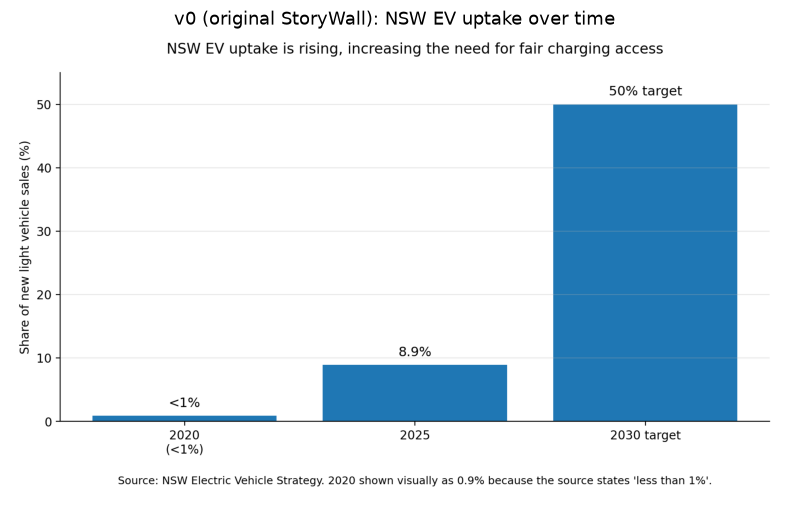

In [13]:
from matplotlib import image as mpimg

v0_path = "nsw_ev_uptake_charging_access_storywall.png"
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(mpimg.imread(v0_path))
ax.axis("off")
ax.set_title("v0 (original StoryWall): NSW EV uptake over time", fontsize=12)
plt.show()

**Rationale / problem with v0.** The chart is clean, but it answers the wrong question. It shows
that EV *demand* is growing, which my TA (planners) already accepts. It does not show whether the
charging *network* is keeping up, and crucially it says nothing about *who* can access charging.
A planner cannot act on it. The CtA is about fair access in outer-suburban areas, so the chart
needs to be about the **supply and distribution of public charging**, not uptake. This motivated
switching to the NSW charging-station dataset.

### v1 - Total public plugs by LGA (raw counts)

First attempt with the right dataset: simply count public plugs in each LGA and show the top 20.

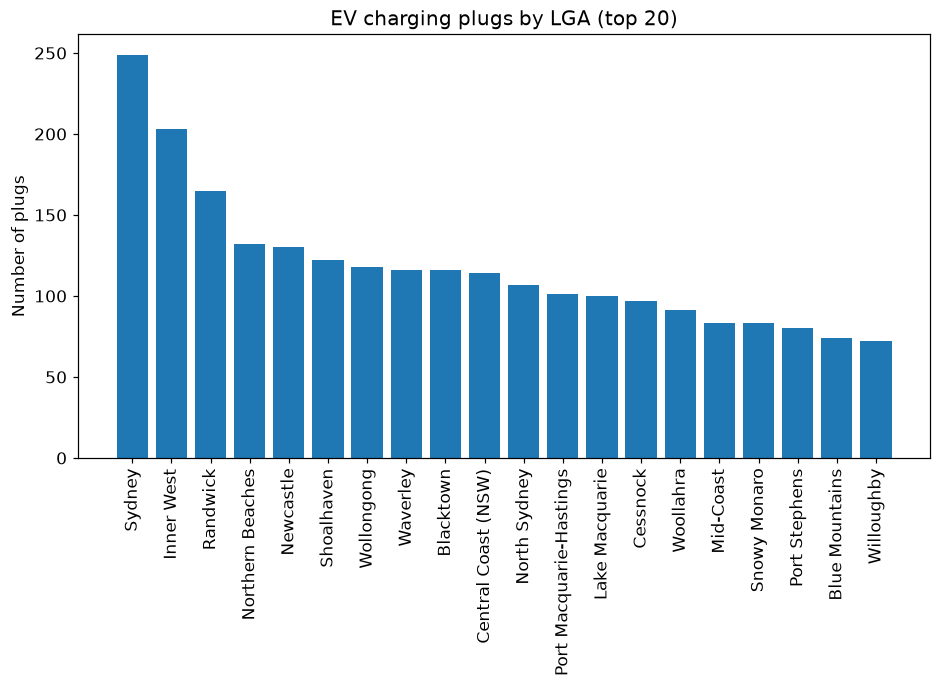

In [14]:
# v1: raw plug counts, top 20 LGAs, default matplotlib styling (intentionally basic).
top20 = full.sort_values("plugs", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top20["lga_name"], top20["plugs"])
ax.set_title("EV charging plugs by LGA (top 20)")
ax.set_ylabel("Number of plugs")
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20["lga_name"], rotation=90)
fig.savefig(OUT / "v1_raw_plugs_by_lga.png")
plt.show()

**Rationale / problem with v1.** Raw counts simply rank LGAs by size: Blacktown, Sydney and the
Northern Beaches top the list because they are large or busy, not because residents are well
served. This actively *hides* the inequity - Blacktown looks "good" with ~116 plugs, but it has
~449,000 residents. Using absolute counts to argue about *fairness* would fail rubric point (d)
"arguments supported by data", because the data does not support a fairness claim. The chart also
has vertical labels that are hard to read. **Fix:** normalise by population.

### v2 - Plugs per 10,000 residents, all 129 NSW LGAs

Normalise to per-capita access and plot every LGA in NSW.

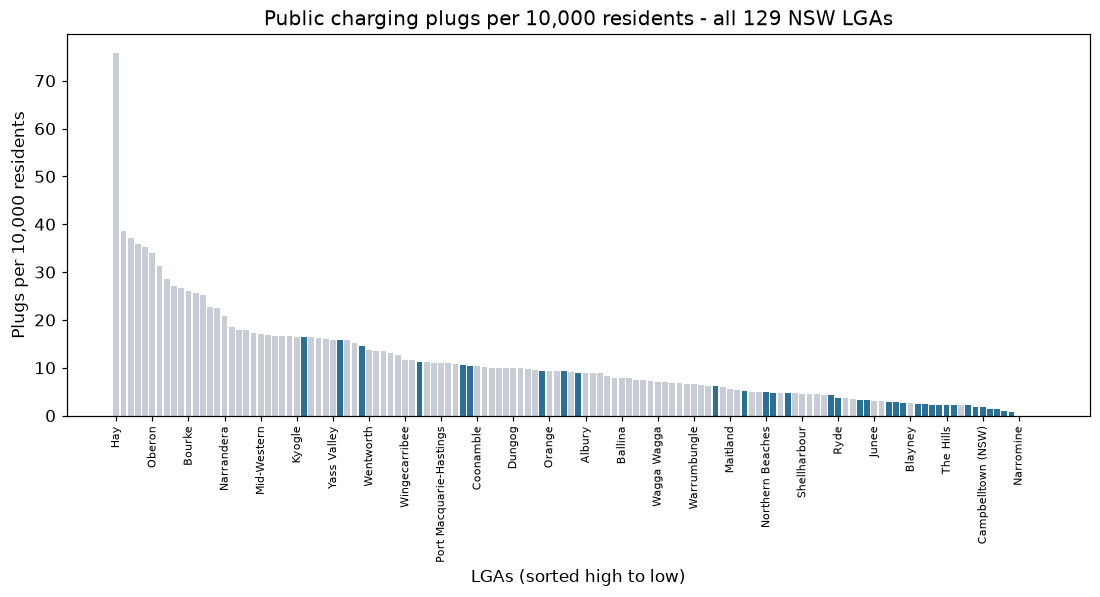

Top per-capita LGAs are tiny tourist/highway towns, e.g.:
            lga_name  erp_2025  plugs  plugs_per_10k
                 Hay    2899.0   22.0      75.888237
Cootamundra-Gundagai   11429.0   44.0      38.498556
        Snowy Monaro   22396.0   83.0      37.060189
          Brewarrina    1396.0    5.0      35.816619
        Edward River    8501.0   30.0      35.289966


In [15]:
# v2: per-capita, but ALL 129 LGAs at once (intentionally over-crowded).
alllga = full.sort_values("plugs_per_10k", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = np.where(alllga["region"] == "Greater Sydney", INNER, MUTED)
ax.bar(range(len(alllga)), alllga["plugs_per_10k"], color=colors)
ax.set_title("Public charging plugs per 10,000 residents - all 129 NSW LGAs")
ax.set_ylabel("Plugs per 10,000 residents")
ax.set_xlabel("LGAs (sorted high to low)")
ax.set_xticks(range(0, len(alllga), 5))
ax.set_xticklabels(alllga["lga_name"].iloc[::5], rotation=90, fontsize=7)
fig.savefig(OUT / "v2_per_capita_all_lgas.png")
plt.show()

print("Top per-capita LGAs are tiny tourist/highway towns, e.g.:")
print(alllga.head(5)[["lga_name", "erp_2025", "plugs", "plugs_per_10k"]]
      .to_string(index=False))

**Rationale / problem with v2.** Per-capita is the correct idea, but two problems appear:
(1) **129 bars is far too many** to read - it violates the "controlled, purposeful" rubric point
and overwhelms the TA. (2) The highest per-capita values are **tiny tourist/highway towns**
(small populations with a destination charger), which makes "Rest of NSW" look better served than
Sydney even though that reflects through-traffic, not resident access. Showing everything at once
buries the real story. **Fix:** focus on a comparable, high-population group - the 34 Greater
Sydney LGAs - where per-capita comparison is fair and where the CtA (outer suburbs) lives.

### v3 - Focused on the 34 Greater Sydney LGAs (sorted)

Restrict to Greater Sydney, where every LGA has a large population, and sort by access.

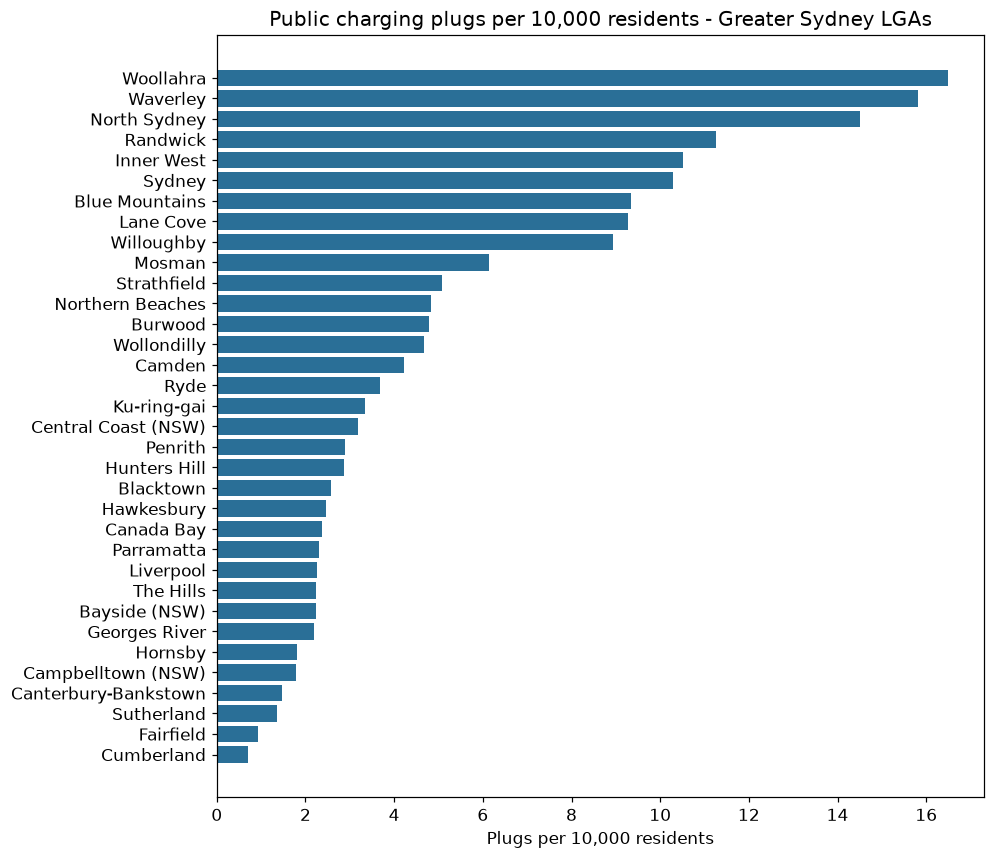

In [16]:
# v3: Greater Sydney only, horizontal bars, single colour (neutral checkpoint).
gs_sorted = full[full["region"] == "Greater Sydney"].sort_values("plugs_per_10k")

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(gs_sorted["lga_name"], gs_sorted["plugs_per_10k"], color=INNER)
ax.set_title("Public charging plugs per 10,000 residents - Greater Sydney LGAs")
ax.set_xlabel("Plugs per 10,000 residents")
fig.savefig(OUT / "v3_greater_sydney_sorted.png")
plt.show()

**Rationale / progress at v3.** This is a big improvement: horizontal bars make the long LGA
names readable, sorting reveals the gradient, and limiting to Greater Sydney removes the
tourist-town distortion so the comparison is fair. The story is now visible - inner/eastern
suburbs (Woollahra, Waverley, North Sydney) sit far above outer-western suburbs (Cumberland,
Fairfield, Canterbury-Bankstown). **But** it is still a neutral "data dump": one flat colour, no
takeaway title, no reference point, and it does not tell the planner where to act. The final
version adds emphasis and a clear message.

### v4 - All 34 Greater Sydney LGAs with emphasis (pre-final version)

This version shows **every** Greater Sydney LGA on a single horizontal bar chart, coloured by
whether access is above or below the metro average. The best-served LGA (Woollahra) is
highlighted in blue as a reference point. This chart tells the full story but is visually dense
(34 bars); the final version below trims it to the 10 worst and 5 best to sharpen the contrast.

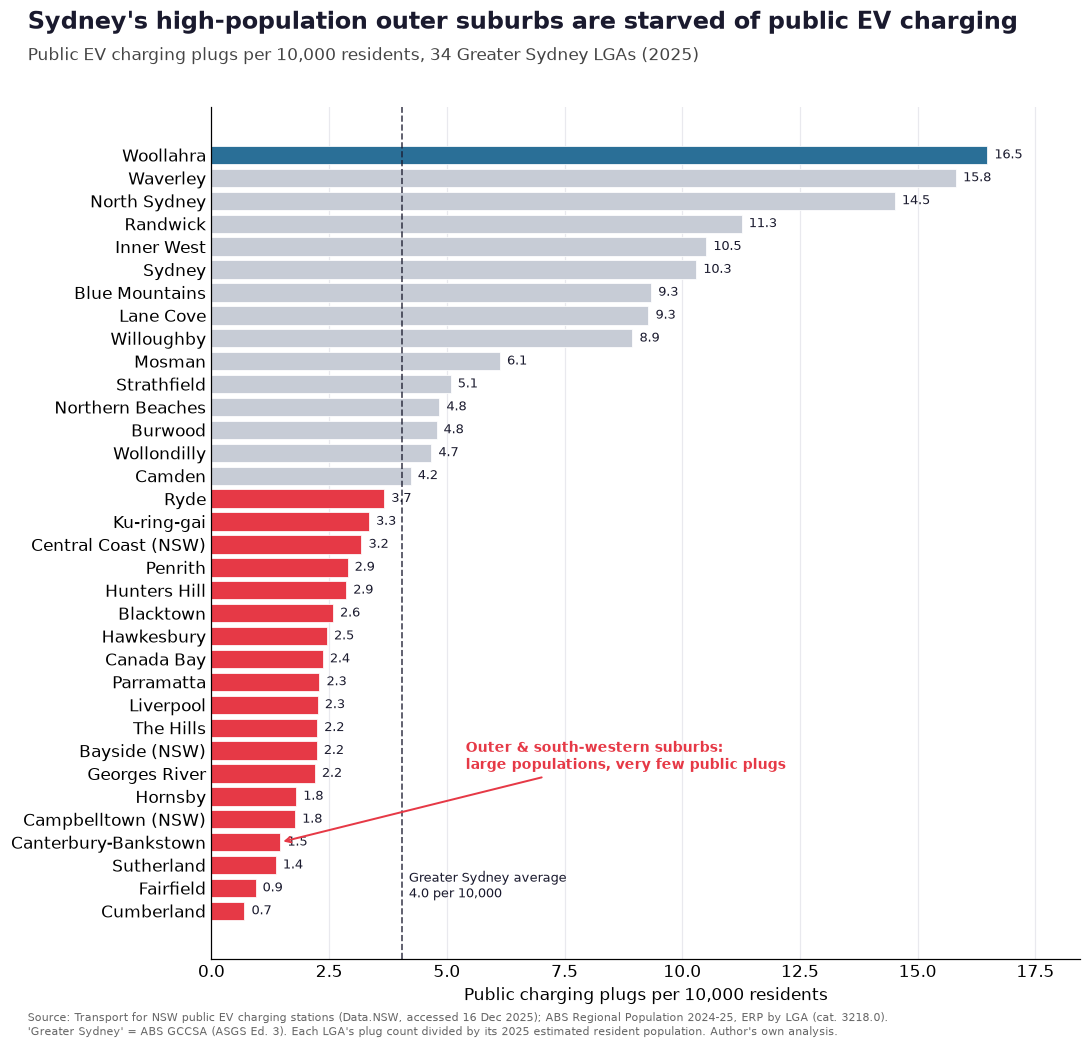

Saved -> outputs/v4_full_34_lgas.png


In [17]:
# v4: all 34 Greater Sydney LGAs with colour emphasis (the chart before the final trim).
gs_chart_v4 = full[full["region"] == "Greater Sydney"].sort_values(
    "plugs_per_10k", ascending=True).reset_index(drop=True)
metro_avg_v4 = gs_chart_v4["plugs"].sum() / gs_chart_v4["erp_2025"].sum() * 10_000

bar_colours_v4 = np.where(gs_chart_v4["plugs_per_10k"] < metro_avg_v4, ACCENT, MUTED)
bar_colours_v4[gs_chart_v4["plugs_per_10k"].idxmax()] = INNER

fig, ax = plt.subplots(figsize=(10, 9.5))
bars = ax.barh(gs_chart_v4["lga_name"], gs_chart_v4["plugs_per_10k"],
               color=bar_colours_v4, edgecolor="white", linewidth=0.5)

for y, v in enumerate(gs_chart_v4["plugs_per_10k"]):
    ax.text(v + 0.15, y, f"{v:.1f}", va="center", ha="left",
            fontsize=8.5, color=INK)

ax.axvline(metro_avg_v4, color=INK, linewidth=1.1, linestyle="--", alpha=0.8)
ax.text(metro_avg_v4 + 0.15, 0.4, f"Greater Sydney average\n{metro_avg_v4:.1f} per 10,000",
        fontsize=8.5, color=INK, va="bottom")

ax.set_title("")
fig.text(0.013, 0.975,
         "Sydney's high-population outer suburbs are starved of public EV charging",
         fontsize=15.5, fontweight="bold", color=INK, ha="left")
fig.text(0.013, 0.945,
         "Public EV charging plugs per 10,000 residents, 34 Greater Sydney LGAs (2025)",
         fontsize=11, color="#444", ha="left")

ax.annotate(
    "Outer & south-western suburbs:\nlarge populations, very few public plugs",
    xy=(gs_chart_v4["plugs_per_10k"].iloc[3], 3),
    xytext=(5.4, 6.2), fontsize=9, color=ACCENT, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.3))

ax.set_xlabel("Public charging plugs per 10,000 residents")
ax.set_xlim(0, gs_chart_v4["plugs_per_10k"].max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="#e9e9ee", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)

fig.text(0.013, 0.012,
         "Source: Transport for NSW public EV charging stations (Data.NSW, accessed 16 Dec 2025); "
         "ABS Regional Population 2024-25, ERP by LGA (cat. 3218.0).\n"
         "'Greater Sydney' = ABS GCCSA (ASGS Ed. 3). Each LGA's plug count divided by its 2025 "
         "estimated resident population. Author's own analysis.",
         fontsize=7.5, color="#666", ha="left")

plt.subplots_adjust(top=0.90, bottom=0.085, left=0.18, right=0.97)
fig.savefig(OUT / "v4_full_34_lgas.png")
plt.show()
print("Saved -> outputs/v4_full_34_lgas.png")

**Rationale / progress at v4.** This chart adds the argumentative layer that v3 lacked: a takeaway
title, colour that separates under-served from well-served LGAs, a metro-average reference line,
and direct value labels. It is a complete, honest visualisation of all 34 Greater Sydney LGAs.
**However**, 34 bars create cognitive load - the eye must scan a long chart and many middle-ranked
LGAs that are neither strikingly bad nor strikingly good dilute the contrast. The final version
below trims to the 10 worst- and 5 best-served LGAs to sharpen the message, while keeping the
metro average computed over all 34 so the benchmark stays honest.

### Final - the chart submitted for Deliverable 2

Building on v4, the final chart keeps the fair per-capita metric and the focused Greater Sydney
scope, but **reduces the 34 LGAs to the 10 most under-served and the 5 best-served** (about half
the bars), separated by a visual gap. This sharpens the contrast and removes the cognitive load
of reading 34 bars (the main weakness of v4), while a labelled gap honestly signals that
middle-ranked LGAs are omitted (not cherry-picked). It retains the takeaway title, metro-average
reference line, colour for the under-served outer suburbs, direct value labels, and full source
caption.

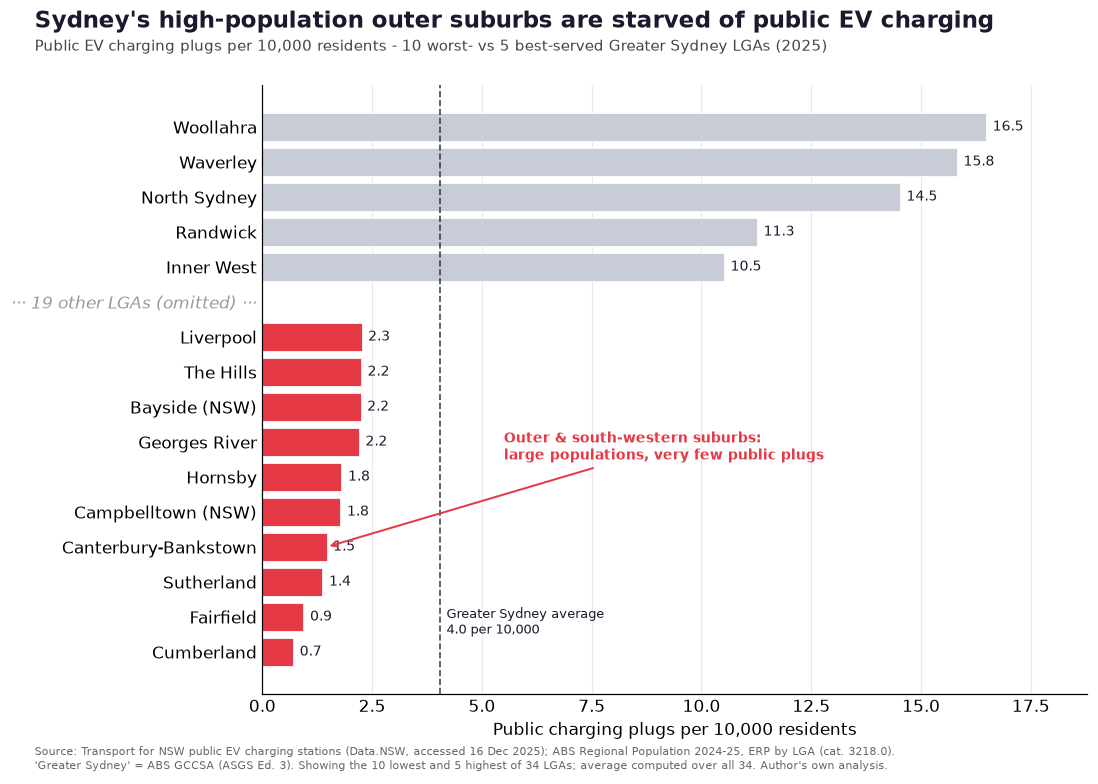

Saved -> outputs/final_sydney_charging_equity.png


In [18]:
# ---- FINAL HERO CHART (reduced to bottom 10 + top 5 of the 34 Greater Sydney LGAs) ----
gs_all = full[full["region"] == "Greater Sydney"].sort_values(
    "plugs_per_10k", ascending=True).reset_index(drop=True)
# Metro average is still computed over ALL 34 LGAs so the benchmark stays honest.
metro_avg = gs_all["plugs"].sum() / gs_all["erp_2025"].sum() * 10_000

# Show the 10 worst-served and 5 best-served LGAs (~half the bars), with a gap between.
N_BOTTOM, N_TOP = 10, 5
bottom = gs_all.head(N_BOTTOM).copy()
top = gs_all.tail(N_TOP).copy()
GAP_LABEL = f"\u00b7\u00b7\u00b7 {len(gs_all) - N_BOTTOM - N_TOP} other LGAs (omitted) \u00b7\u00b7\u00b7"
gap_row = pd.DataFrame([{"lga_name": GAP_LABEL, "plugs_per_10k": 0,
                         "plugs": 0, "erp_2025": 0}])
gs_chart = pd.concat([bottom, gap_row, top], ignore_index=True)

# Colour: red = below metro average (under-served); everything else one neutral grey.
bar_colours = []
for i, row in gs_chart.iterrows():
    if row["lga_name"] == GAP_LABEL:
        bar_colours.append("none")
    elif row["plugs_per_10k"] < metro_avg:
        bar_colours.append(ACCENT)
    else:
        bar_colours.append(MUTED)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = list(range(len(gs_chart)))
bars = ax.barh(y_pos, gs_chart["plugs_per_10k"],
               color=bar_colours, edgecolor="white", linewidth=0.5)

# Direct value labels at the end of each bar (skip the gap row).
for y, (_, row) in zip(y_pos, gs_chart.iterrows()):
    if row["lga_name"] != GAP_LABEL:
        ax.text(row["plugs_per_10k"] + 0.15, y, f"{row['plugs_per_10k']:.1f}",
                va="center", ha="left", fontsize=9, color=INK)

ax.set_yticks(y_pos)
ax.set_yticklabels(gs_chart["lga_name"])
ax.get_yticklabels()[N_BOTTOM].set_fontstyle("italic")
ax.get_yticklabels()[N_BOTTOM].set_color("#999")

# Metro-average reference line.
ax.axvline(metro_avg, color=INK, linewidth=1.1, linestyle="--", alpha=0.8)
ax.text(metro_avg + 0.15, 0.4, f"Greater Sydney average\n{metro_avg:.1f} per 10,000",
        fontsize=8.5, color=INK, va="bottom")

# Takeaway title + subtitle (left-aligned, headline first).
ax.set_title("")
fig.text(0.013, 0.975,
         "Sydney's high-population outer suburbs are starved of public EV charging",
         fontsize=15, fontweight="bold", color=INK, ha="left")
fig.text(0.013, 0.945,
         "Public EV charging plugs per 10,000 residents - 10 worst- vs 5 best-served Greater Sydney LGAs (2025)",
         fontsize=10, color="#444", ha="left")

# Annotation pointing at the under-served cluster.
ax.annotate(
    "Outer & south-western suburbs:\nlarge populations, very few public plugs",
    xy=(gs_chart["plugs_per_10k"].iloc[3], 3),
    xytext=(5.5, 5.5), fontsize=9, color=ACCENT, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.3))

ax.set_xlabel("Public charging plugs per 10,000 residents")
ax.set_xlim(0, gs_chart["plugs_per_10k"].max() * 1.14)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="#e9e9ee", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)

fig.text(0.013, 0.012,
         "Source: Transport for NSW public EV charging stations (Data.NSW, accessed 16 Dec 2025); "
         "ABS Regional Population 2024-25, ERP by LGA (cat. 3218.0).\n"
         "'Greater Sydney' = ABS GCCSA (ASGS Ed. 3). Showing the 10 lowest and 5 highest of 34 LGAs; "
         "average computed over all 34. Author's own analysis.",
         fontsize=7.5, color="#666", ha="left")

plt.subplots_adjust(top=0.90, bottom=0.11, left=0.22, right=0.97)
fig.savefig(OUT / "final_sydney_charging_equity.png")
plt.show()
print("Saved -> outputs/final_sydney_charging_equity.png")

**Why the final version meets the Data Analysis & Visualisation criteria**

- **(a) Reputable, reliable sources** - Transport for NSW charging data (Data.NSW) and ABS Regional Population, both government open data, cited in full in the caption and in Section 1.
- **(b) Course design principles** - one clear takeaway title stating the message; colour used sparingly and purposefully (red only for the under-served, below-average LGAs; a single neutral grey for every other bar so attention is not split); top/right spines removed; light gridlines sit behind the data; direct value labels remove the need to read off an axis; horizontal bars make LGA names legible. Reducing 34 bars to the 10 worst- and 5 best-served LGAs cuts clutter and lets the eye lock onto the contrast immediately.
- **(c) Understandable by the TA** - a planner can read the headline, scan to their LGA, and see instantly whether it is above or below the metro average. Showing only the extremes makes the gap obvious at a glance, with no specialist knowledge needed.
- **(d) Arguments supported by data** - the fairness claim is backed by a per-capita metric, and the metro-average line is still computed over **all 34** Greater Sydney LGAs, so the benchmark is honest even though only 15 bars are drawn. The labelled gap ("other LGAs omitted") signals transparency, not cherry-picking.
- **(e) Controlled number of charts** - the iterations above are process documentation; the **single** final chart is the deliverable, and it has one clear purpose: show where charging access per resident is lowest.

**The data story this supports.** Public EV charging in Greater Sydney is highly uneven. Affluent
inner suburbs such as Woollahra (~16 plugs/10k) have several times the public charging of large
outer-western and south-western suburbs such as Cumberland, Fairfield and Canterbury-Bankstown
(under ~1.5 plugs/10k) - the very areas where households are least likely to have off-street
home charging. This evidences the CtA: planners should prioritise public charging rollout in
these under-served outer suburbs so the EV transition is fair.

## 5. References

1. Transport for NSW / NSW Government. *Electric vehicle charging stations (NSW)*. Data.NSW. Licensed CC-BY 4.0. <https://data.nsw.gov.au/data/dataset/electric-vehicle-charging-points> (data file `ev_20251216.csv`, accessed 16 Dec 2025).
2. Australian Bureau of Statistics. *Regional population, 2024-25 financial year* (cat. 3218.0), data cube *Population estimates and components by LGA* (`32180DS0002_2024-25.xlsx`). Licensed CC-BY 4.0. <https://www.abs.gov.au/statistics/people/population/regional-population/latest-release> (accessed 24 Jun 2026).
3. Australian Bureau of Statistics. *Australian Statistical Geography Standard (ASGS) Edition 3, Greater Capital City Statistical Areas (Greater Sydney)*. <https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026> (accessed 24 Jun 2026).
4. NSW Government. *NSW Electric Vehicle Strategy* (EV uptake targets used in the v0 StoryWall chart). <https://www.energy.nsw.gov.au/business-and-industry/programs-grants-and-schemes/electric-vehicles> (accessed 16 Dec 2025).
